# VGG16 CIFAR10 Training: TF32 Base + FP8 Low Precision

Notebook ini melatih model **VGG16** pada dataset **CIFAR-10** menggunakan konfigurasi mixed-precision:

| Komponen | Precision | Keterangan |
|----------|-----------|------------|
| **Base precision** | TF32 | Diaktifkan via `torch.backends.cuda.matmul.allow_tf32 = True`. TF32 menggunakan 10-bit mantissa (vs 23-bit FP32) dengan exponent range FP32 penuh. |
| **Low precision** | FP8 (E4M3) | Diterapkan pada Conv2d dan Linear layers terpilih menggunakan native FP8 casting + delayed scaling. |

### Arsitektur Precision Assignment
- **Conv layers 0-6** (64→64→128→128→256→256→256): FP8 — layer-layer awal yang compute-intensive
- **Conv layers 7-12** (512 channels): TF32 — layer akhir yang lebih sensitif terhadap precision
- **Linear layer 0** (512→512): FP8 — FC layer pertama yang paling besar
- **Linear layers 1-2**: TF32 — classifier layers yang perlu precision lebih tinggi

### Key Concepts
- **Delayed Scaling**: Scale factor dihitung dari amax history (16 iterasi), bukan per-batch
- **FP8 E4M3**: 4-bit exponent, 3-bit mantissa, range ±448 — cocok untuk forward activations & weights
- **NativePrecisionMixin**: Setiap layer bisa di-assign precision mode secara independen

In [1]:
# ============================================================
# Cell 2: Imports & Environment Check
# ============================================================

import os, sys
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ---- Add project root to sys.path ----
PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
print(f'[INFO] Project root: {PROJECT_ROOT}')

# ---- Import ext3 modules ----
from ext3.nn import flatten
from ext3.nn.nn_native import (
    NativeConv2d, NativeLinear, NativeBatchNorm2d,
    NativeReLU, NativeMaxPool2d, NativeAdaptiveAvgPool2d,
    NativeDropout, reset_fp8_manager
)
from ext3.core.include.native_precision import (
    NativePrecisionMode, check_fp8_support, enable_tf32, FP8Config
)
from ext3.core.emodlobj import EModlObjMgr
from ext3.core.include.dtype import Dtype, FP32
from ext3.core.include.pasn import Pasn
from ext3.core.include.ttype import Ttype

# Environment Check
print(f"\n=== Environment Check ===")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name       : {torch.cuda.get_device_name(0)}")
print(f"FP8 Supported  : {check_fp8_support()}")


[INFO] Project root: c:\Users\PC\Documents\penelitian_miftah\github_remote\Adaptive-Precision-Assigment

=== Environment Check ===
PyTorch Version: 2.12.1+cu132
CUDA Available : True
GPU Name       : NVIDIA GeForce RTX 5060 Ti
FP8 Supported  : True


In [2]:
# ============================================================
# Cell 3: Global Configuration
# ============================================================

enable_tf32()

CONFIG = {
    'batch_size': 128,
    'epochs': 50,
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 5e-4,
    'num_workers': 0,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # --- Native APA (Adaptive Precision Assignment) Config ---
    'pa_upd_schm': 'topr_dec',    # Demote layer terbesar lebih dulu
    'pa_upd_rmin': 0.3,           # Target 30% dari total parameter
    'pa_upd_rmax': 0.4,           
}

print("\n=== Training Configuration ===")
for k, v in CONFIG.items():
    print(f"  {k:20s}: {v}")



=== Training Configuration ===
  batch_size          : 128
  epochs              : 50
  lr                  : 0.01
  momentum            : 0.9
  weight_decay        : 0.0005
  num_workers         : 0
  device              : cuda
  pa_upd_schm         : topr_dec
  pa_upd_rmin         : 0.3
  pa_upd_rmax         : 0.4


In [3]:
# ============================================================
# Cell 4: VGG16 Model Definition
# ============================================================
# Menggunakan ext3 Native layers agar setiap Conv2d/Linear bisa
# di-assign precision mode secara independen (TF32 atau FP8).
# Diadaptasi untuk CIFAR-10 (input 32x32, output 10 classes).

# VGG16 feature config: angka = jumlah filter, 'M' = MaxPool2d
VGG16_CFG = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']


class VGG16Native(nn.Module):
    """
    VGG16 dengan NativeConv2d/NativeLinear untuk mixed-precision.
    
    Struktur:
      features: 13 NativeConv2d + NativeBatchNorm2d + NativeReLU + 5 NativeMaxPool2d
      avgpool : NativeAdaptiveAvgPool2d(1, 1) — output 512x1x1
      classifier: 3 NativeLinear (512→512→512→10)
    """

    def __init__(self, num_classes: int = 10):
        super(VGG16Native, self).__init__()
        
        # Build feature extractor dari VGG16 config
        self.features = self._make_layers(VGG16_CFG)
        
        # AdaptiveAvgPool menangani arbitrary input size → 1x1
        # Untuk CIFAR-10 (32x32), setelah 5 MaxPool: 32→16→8→4→2→1
        self.avgpool = NativeAdaptiveAvgPool2d((1, 1))
        
        # Classifier: 3 fully-connected layers
        # Original VGG: 512*7*7→4096→4096→1000
        # CIFAR-10 adapted: 512→512→512→10
        self.classifier = nn.Sequential(
            NativeLinear(512, 512),
            NativeReLU(inplace=False),
            NativeDropout(p=0.5),
            NativeLinear(512, 512),
            NativeReLU(inplace=False),
            NativeDropout(p=0.5),
            NativeLinear(512, num_classes),
        )
        
        # Weight initialization (Kaiming untuk Conv, Xavier untuk Linear)
        self._initialize_weights()

    def _make_layers(self, cfg):
        """Build feature extractor dari VGG config list."""
        layers = []
        in_channels = 3  # CIFAR-10: RGB input
        
        for v in cfg:
            if v == 'M':
                layers.append(NativeMaxPool2d(kernel_size=2, stride=2))
            else:
                # Conv2d → BatchNorm2d → ReLU
                layers.append(NativeConv2d(in_channels, v, kernel_size=3, padding=1))
                layers.append(NativeBatchNorm2d(v))
                layers.append(NativeReLU(inplace=False))
                in_channels = v
        
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        """Inisialisasi weights menggunakan Kaiming/Xavier."""
        for m in self.modules():
            if isinstance(m, NativeConv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, NativeBatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, NativeLinear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.avgpool(x)
        x = flatten(x, 1)  # Flatten: [B, 512, 1, 1] → [B, 512]
        x = self.classifier(x)
        return x


# Quick architecture verification
print("=== VGG16Native Architecture ===")
_model_test = VGG16Native(num_classes=10)

# Count layers
_n_conv = sum(1 for m in _model_test.modules() if isinstance(m, NativeConv2d))
_n_linear = sum(1 for m in _model_test.modules() if isinstance(m, NativeLinear))
_n_params = sum(p.numel() for p in _model_test.parameters())

print(f"  NativeConv2d layers : {_n_conv}")
print(f"  NativeLinear layers : {_n_linear}")
print(f"  Total parameters    : {_n_params:,}")
print(f"  Parameters (MB)     : {_n_params * 4 / 1024**2:.1f}")


=== VGG16Native Architecture ===
  NativeConv2d layers : 13
  NativeLinear layers : 3
  Total parameters    : 15,253,578
  Parameters (MB)     : 58.2


In [4]:
# ============================================================
# Cell 5: Precision Assignment Setup
# ============================================================

from ext3.util.apa_manager import assign_precision, check_and_promote_overflow
print("APA Manager functions imported ✓")


assign_precision() defined ✓


In [5]:
# ============================================================
# Cell 6: CIFAR-10 Data Pipeline
# ============================================================
# Standard data augmentation untuk CIFAR-10:
# - RandomCrop(32, padding=4): spatial augmentation
# - RandomHorizontalFlip: mirror augmentation
# - Normalize: channel-wise mean/std normalization

# CIFAR-10 channel statistics (precomputed)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

# Training transforms: augmentation + normalization
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Test transforms: normalization only
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Download & create datasets
trainset = torchvision.datasets.CIFAR10(
    root="./dataset/cifar10", train=True, download=True, transform=transform_train
)
testset = torchvision.datasets.CIFAR10(
    root="./dataset/cifar10", train=False, download=True, transform=transform_test
)

# Create dataloaders
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True,
)

# CIFAR-10 class names
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"\n=== CIFAR-10 Dataset ===")
print(f"  Training samples   : {len(trainset):,}")
print(f"  Test samples       : {len(testset):,}")
print(f"  Batch size         : {CONFIG['batch_size']}")
print(f"  Training batches   : {len(trainloader)}")
print(f"  Test batches       : {len(testloader)}")
print(f"  Classes            : {len(CLASSES)}")


=== CIFAR-10 Dataset ===
  Training samples   : 50,000
  Test samples       : 10,000
  Batch size         : 128
  Training batches   : 391
  Test batches       : 79
  Classes            : 10


In [6]:
# ============================================================
# Cell 7: VRAM Monitoring Utility
# ============================================================

def get_vram_mb() -> float:
    """Return current GPU memory allocated in MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024 ** 2)
    return 0.0


def get_vram_peak_mb() -> float:
    """Return peak GPU memory allocated in MB."""
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return 0.0


def print_vram_status(label: str = ""):
    """Print current and peak VRAM usage."""
    current = get_vram_mb()
    peak = get_vram_peak_mb()
    prefix = f"[{label}] " if label else ""
    print(f"  {prefix}VRAM: {current:.1f} MB (current) / {peak:.1f} MB (peak)")


print("VRAM monitoring utilities defined ✓")
if torch.cuda.is_available():
    print_vram_status("Initial")

VRAM monitoring utilities defined ✓
  [Initial] VRAM: 0.0 MB (current) / 0.0 MB (peak)


In [7]:
# ============================================================
# Cell 8: Training Function
# ============================================================

def train_epoch(model, loader, criterion, optimizer, device, ovr_thrs=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        # --- NATIVE APA: Precision Promotion ---
        check_and_promote_overflow(ovr_thrs, FP32)
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    # Dapatkan jumlah promosi epoch ini
    flags = EModlObjMgr.get_inc_ts_prec_flag()
    total_promotions = sum([1 for f in flags if f > 0.0])
    
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, total_promotions

print("train_epoch() defined ✓")


train_epoch() defined ✓


In [8]:
# ============================================================
# Cell 9: Evaluation Function
# ============================================================

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    Evaluate model pada test/validation set.
    
    Menggunakan torch.no_grad() untuk menghemat memory dan
    mempercepat inference (tidak perlu menyimpan gradients).
    
    Args:
        model: VGG16Native model
        loader: Test DataLoader
        criterion: Loss function
        device: 'cuda' atau 'cpu'
    
    Returns:
        tuple: (avg_loss, accuracy_percent)
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    avg_loss = total_loss / total
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy


print("evaluate() defined ✓")

evaluate() defined ✓


In [9]:
# ============================================================
# Cell 10: Main Training Loop
# ============================================================

model = VGG16Native(num_classes=10).to(CONFIG['device'])

reset_fp8_manager()
pasn_manager = assign_precision(model, CONFIG)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=CONFIG['lr'], 
                      momentum=CONFIG['momentum'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

history = {
    'train_loss': [],
    'train_acc': [],
    'test_acc': [],
    'vram': [],
    'lr': [],
    'promotions': [],
}

print("\n" + "=" * 90)
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'Promoted':>8} | {'VRAM MB':>8} | {'Time':>6} | {'LR':>8}")
print("-" * 90)

best_acc = 0.0
cumulative_promotions = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    start_time = time.time()
    current_lr = optimizer.param_groups[0]['lr']
    
    train_loss, train_acc, promotions = train_epoch(
        model, trainloader, criterion, optimizer, CONFIG['device']
    )
    _, test_acc = evaluate(model, testloader, criterion, CONFIG['device'])
    scheduler.step()
    
    epoch_time = time.time() - start_time
    vram = get_vram_mb()
    cumulative_promotions += promotions
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['vram'].append(vram)
    history['lr'].append(current_lr)
    history['promotions'].append(cumulative_promotions)
    
    best_marker = " *" if test_acc > best_acc else ""
    best_acc = max(best_acc, test_acc)
    
    print(f"{epoch:5d} | {train_loss:10.4f} | {train_acc:8.2f}% | {test_acc:7.2f}% | {promotions:5d} ↑ | {vram:7.1f}M | {epoch_time:5.1f}s | {current_lr:.6f}{best_marker}")

print("=" * 90)
print(f"Training Complete! Best Test Accuracy: {best_acc:.2f}%")
print(f"Total layers promoted to TF32/FP32: {cumulative_promotions}")



PRECISION ASSIGNMENT (Original APA Architecture)
  Target Demotion Ratio : 0.300
  Total Layers          : 52
  Demoted Layers        : 1

=== Grouping & Demotion Map ===
Group   0 | NativeConv2d                   | Y=base_tf32  P=base_tf32 
Group   0 | NativeBatchNorm2d              | Y=base_tf32  P=base_tf32 
Group   0 | NativeReLU                     | Y=base_tf32  P=base_tf32 
Group   1 | NativeConv2d                   | Y=low_fp8    P=base_tf32  [DEMOTED: Y=FP8]
Group   1 | NativeBatchNorm2d              | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeReLU                     | Y=low_fp8    P=base_tf32  [DEMOTED: Y=FP8]
Group   1 | NativeMaxPool2d                | Y=low_fp8    P=base_tf32  [DEMOTED: Y=FP8]
Group   1 | NativeConv2d                   | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeBatchNorm2d              | Y=low_fp8    P=low_fp8    [DEMOTED: Y=FP8, P=FP8]
Group   1 | NativeReLU                     | Y=low_fp8    P=base_t

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


    1 |     1.9325 |    27.06% |   37.46% |    15 ↑ |   242.2M |  24.6s | 0.010000 *
    2 |     1.5802 |    41.44% |   41.72% |     0 ↑ |   242.2M |  26.4s | 0.009990 *
    3 |     1.4354 |    48.38% |   46.94% |     0 ↑ |   242.2M |  26.7s | 0.009961 *
    4 |     1.3788 |    51.32% |   24.86% |     0 ↑ |   242.2M |  26.2s | 0.009911
    5 |     1.3265 |    53.47% |   52.66% |     0 ↑ |   242.2M |  26.2s | 0.009843 *
    6 |     1.2598 |    56.01% |   48.39% |     0 ↑ |   242.2M |  26.3s | 0.009755
    7 |     1.2022 |    58.07% |   37.03% |     0 ↑ |   242.2M |  26.7s | 0.009649
    8 |     1.1609 |    59.99% |   50.81% |     0 ↑ |   242.2M |  26.2s | 0.009524
    9 |     1.1244 |    61.29% |   52.97% |     0 ↑ |   242.2M |  26.8s | 0.009382 *
   10 |     1.0769 |    63.27% |   55.92% |     0 ↑ |   242.2M |  27.1s | 0.009222 *
   11 |     1.0180 |    65.33% |   59.89% |     0 ↑ |   242.2M |  26.3s | 0.009045 *
   12 |     0.9917 |    66.25% |   63.99% |     0 ↑ |   242.2M |  26.9s |

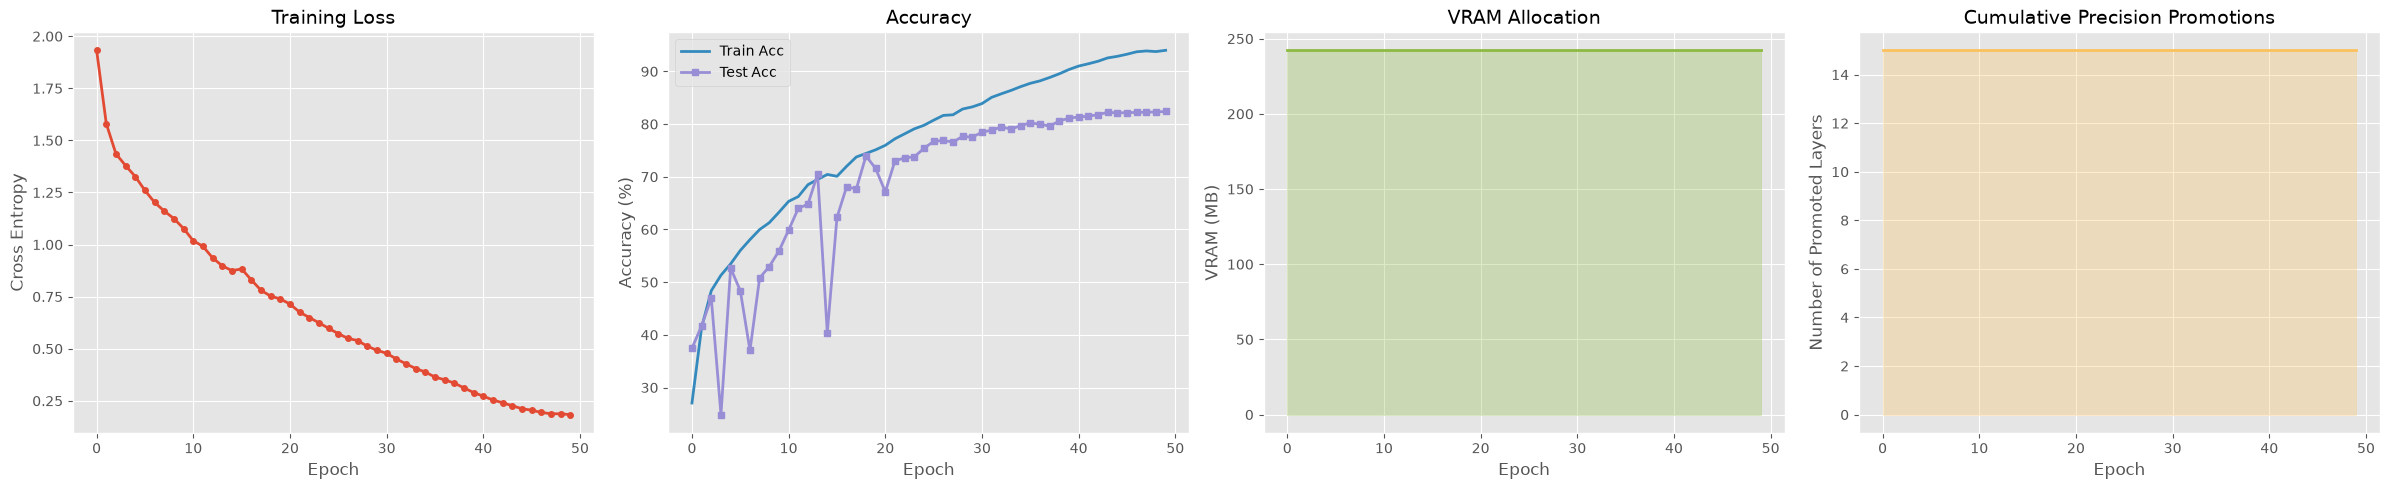

In [10]:
# ============================================================
# Cell 11: Visualization (Termasuk Promotion Plot)
# ============================================================

plt.style.use('ggplot')
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 5))

# 1. Loss Curve
ax1.plot(history['train_loss'], color='#E24A33', linewidth=2, marker='o', markersize=4)
ax1.set_title('Training Loss', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross Entropy', fontsize=12)

# 2. Accuracy Curve
ax2.plot(history['train_acc'], label='Train Acc', color='#348ABD', linewidth=2)
ax2.plot(history['test_acc'], label='Test Acc', color='#988ED5', linewidth=2, marker='s', markersize=4)
ax2.set_title('Accuracy', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend()

# 3. VRAM Usage
ax3.plot(history['vram'], color='#8EBA42', linewidth=2, fillstyle='bottom')
ax3.fill_between(range(len(history['vram'])), history['vram'], alpha=0.3, color='#8EBA42')
ax3.set_title('VRAM Allocation', fontsize=14)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('VRAM (MB)', fontsize=12)

# 4. Cumulative Promotions
ax4.plot(history['promotions'], color='#FBC15E', linewidth=2, drawstyle='steps-post')
ax4.fill_between(range(len(history['promotions'])), history['promotions'], alpha=0.3, color='#FBC15E', step='post')
ax4.set_title('Cumulative Precision Promotions', fontsize=14)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Number of Promoted Layers', fontsize=12)

plt.tight_layout()
plt.savefig('vgg16_tf32_fp8_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Analisis: TF32 Base + FP8 Low Precision

### Mengapa Kombinasi TF32 + FP8?

**TF32 sebagai Base Precision:**
- TF32 (TensorFloat-32) menggunakan 10-bit mantissa dengan exponent range FP32 penuh
- Pada GPU Ampere ke atas, TF32 memberikan **~2-3x speedup** untuk matmul dan convolution
- Tidak memerlukan perubahan kode apapun — cukup set global flag
- Akurasi sangat mendekati FP32 penuh untuk hampir semua use case

**FP8 sebagai Low Precision (Selected Layers):**
- FP8 E4M3 (4-bit exponent, 3-bit mantissa) memiliki range ±448
- Cocok untuk layer-layer awal (conv 0-6) yang memproses fitur low-level
- **Delayed scaling** menjaga stabilitas: scale factor dihitung dari 16-iterasi history
- Hanya applied pada forward pass; backward tetap FP32 untuk stabilitas gradient

### Strategi Layer Assignment

| Layer Group | Precision | Alasan |
|-------------|-----------|--------|
| Conv2d 0-6 (64-256 ch) | FP8 | Layer awal: toleran terhadap noise, high compute ratio |
| Conv2d 7-12 (512 ch) | TF32 | Layer akhir: semantic features sensitif terhadap precision |
| Linear 0 (512→512) | FP8 | FC layer terbesar, dominan compute |
| Linear 1-2 (512→10) | TF32 | Classifier output, perlu precision tinggi |

### Keuntungan Mixed Precision

1. **Memory Efficiency**: FP8 weights dan activations menggunakan 1 byte vs 4 bytes (FP32)
2. **Compute Throughput**: FP8 tensor cores memberikan throughput lebih tinggi
3. **Training Stability**: Delayed scaling mencegah overflow/underflow
4. **Selective Application**: Hanya layer yang toleran yang menggunakan FP8

### Catatan Penting
- FP8 memerlukan GPU dengan compute capability ≥ 8.9 (Ada Lovelace) atau ≥ 9.0 (Hopper)
- Pada GPU yang tidak mendukung FP8, framework otomatis fallback ke FP16
- BatchNorm selalu beroperasi di FP32 (best practice untuk running statistics)